In [1]:
import numpy as np
from scipy.integrate import quad
from math import pi as PI
import matplotlib.pyplot as plt

# With astropy

In [2]:
%matplotlib inline
from IPython.display import Image

In [3]:
from astropy.cosmology import FlatLambdaCDM
import astropy.units as u

In [4]:
cosmo = FlatLambdaCDM(H0=70*u.km/u.s/u.Mpc, Om0=0.3)

In [5]:
zvals = np.arange(0, 13.1, 0.1)
dist = cosmo.angular_diameter_distance(zvals)

Text(0, 0.5, 'angular diameter distance (Mpc)')

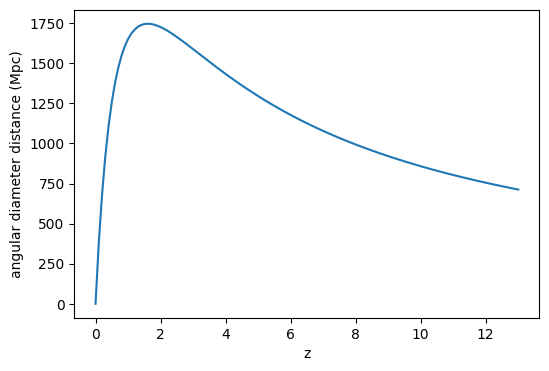

In [6]:
fig = plt.figure(figsize=(6,4))
ax = fig.add_subplot(111)
ax.plot(zvals, dist)
ax.set_xlabel('z')
ax.set_ylabel(f'angular diameter distance ({dist.unit})')

In [7]:
ages = np.array([13, 10, 8, 6, 5, 4, 3, 2, 1.5, 1.2, 1])*u.Gyr

In [8]:
from astropy.cosmology import z_at_value
ageticks = [z_at_value(cosmo.age, age) for age in ages]

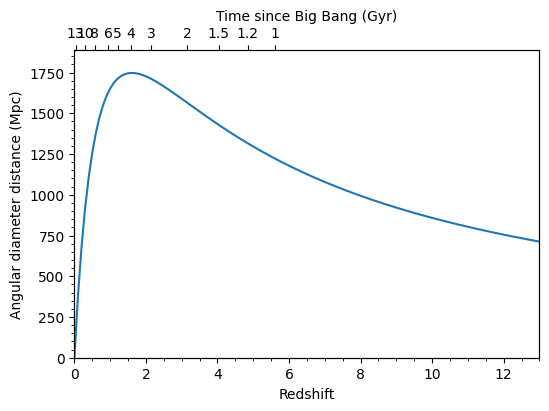

In [9]:
fig = plt.figure(figsize=(6,4))
ax = fig.add_subplot(111)
ax.plot(zvals, dist)
ax2 = ax.twiny()
ax2.set_xticks(ageticks)
ax2.set_xticklabels(['{:g}'.format(age) for age in ages.value])
zmin, zmax = 0.0, 13
ax.set_xlim(zmin, zmax)
ax2.set_xlim(zmin, zmax)
ax2.set_xlabel('Time since Big Bang (Gyr)')
ax.set_xlabel('Redshift')
ax.set_ylabel('Angular diameter distance (Mpc)')
ax.set_ylim(0, 1890)
ax.minorticks_on()

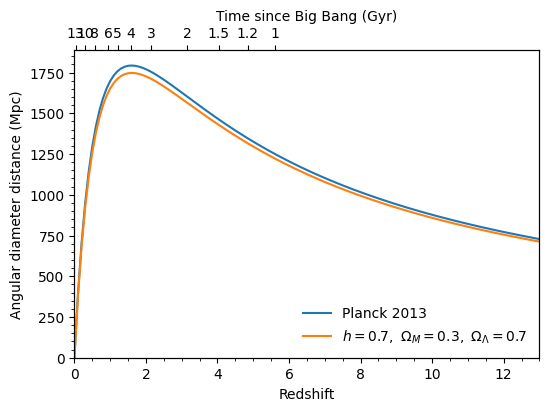

In [11]:
from astropy.cosmology import Planck13
dist2 = Planck13.angular_diameter_distance(zvals)

fig = plt.figure(figsize=(6,4))
ax = fig.add_subplot(111)
ax.plot(zvals, dist2, label='Planck 2013')
ax.plot(zvals, dist, label=r'$h=0.7,\ \Omega_M=0.3,\ \Omega_\Lambda=0.7$')
ax.legend(frameon=0, loc='lower right')
ax2 = ax.twiny()
ax2.set_xticks(ageticks)
ax2.set_xticklabels(['{:g}'.format(age) for age in ages.value])
zmin, zmax = 0.0, 13
ax.set_xlim(zmin, zmax)
ax2.set_xlim(zmin, zmax)
ax2.set_xlabel('Time since Big Bang (Gyr)')
ax.set_xlabel('Redshift')
ax.set_ylabel('Angular diameter distance (Mpc)')
ax.minorticks_on()
ax.set_ylim(0, 1890)
# fig.savefig('ang_dist.png', dpi=200, bbox_inches='tight')
plt.show()

# Define Constants

In [5]:
c = 299792.458 # speed of light km/s
a0 = 1. # scale factor at present time
H0 = 70 # Hubble's constant km/s/Mpc

WM = 0.3 # matter density parameter
WV = 0.7 # vacuum density parameter
WR = 0. # radiation density parameter
WK = 0. # curvature density parameter

h = H0/100
WR = 4.165e-5/h**2
WK = 1-WM-WR-WV

In [7]:
# Conversion factors
arcsec = 2*PI/360/60/60
Tyr = 977.8 # coefficent for converting 1/H into Gyr

In [9]:
z_arr = np.linspace(0,13,1000)

In [25]:
quad(lambda a : 1/adot(a),0,a(1))

(0.4114397345657252, 8.389964687669958e-10)

In [21]:
a = lambda z : 1/(1+z)
adot = lambda a : (WM/a + WR/a**2 + WV*a**2 + WK)**.5
age = np.array([quad(lambda a : 1/adot(a),0,a(z))[0] for z in z_arr])
distance = np.array([quad(lambda a : 1/adot(a)*1/a,a(z),1)[0] for z in z_arr])

In [27]:
ratio = 1. # Something to do with the curvature of the universe.

DA = []

for z, d in zip(z_arr, distance):
    x = abs(WK)**.5*d
    if x > 0.1:
        if WK > 0:
          ratio =  0.5*(exp(x)-exp(-x))/x 
        else:
          ratio = sin(x)/x
    else:
        y = x*x
        if WK < 0:
            y = -y
        ratio = 1. + y/6. + y*y/120.
    DCMT = ratio*d
    DA.append(a(z)*DCMT)
DA = np.array(DA)

In [32]:
age_Gyr = age * (Tyr/H0)
distance_Mpc = distance * (c/H0)
DA_Mpc = DA * (c/H0)
res = DA * 1000*arcsec * (c/H0)

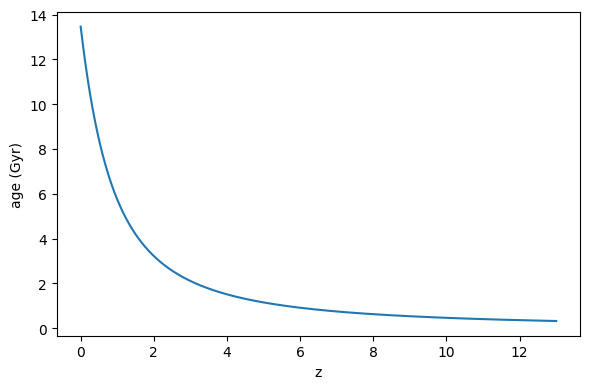

In [30]:
fig, ax = plt.subplots(1,1,figsize=(6,4),tight_layout=True)

ax.set_xlabel("z")
ax.set_ylabel("age (Gyr)")

ax.plot(z_arr,age_Gyr)

plt.show()

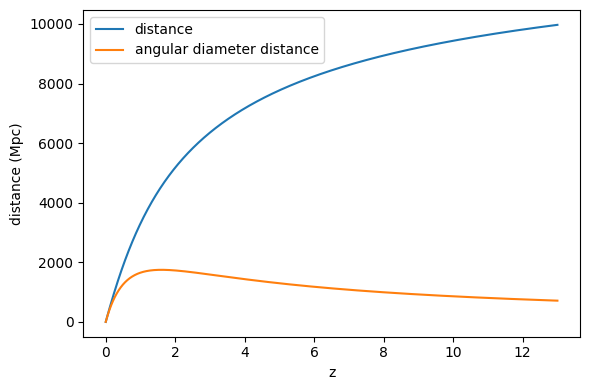

In [34]:
fig, ax = plt.subplots(1,1,figsize=(6,4),tight_layout=True)

ax.set_xlabel("z")
ax.set_ylabel("distance (Mpc)")

ax.plot(z_arr,distance_Mpc,label="distance")
ax.plot(z_arr,DA_Mpc,label="angular diameter distance")

ax.legend()

plt.show()

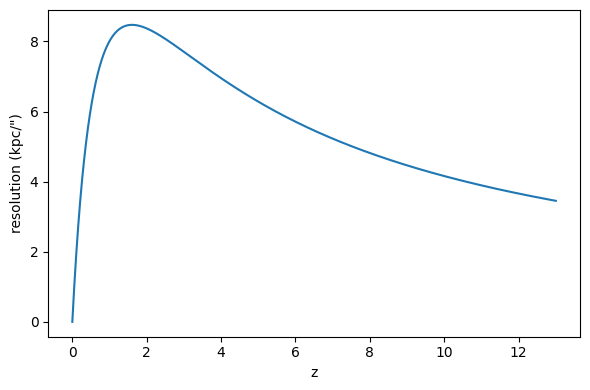

In [35]:
fig, ax = plt.subplots(1,1,figsize=(6,4),tight_layout=True)

ax.set_xlabel("z")
ax.set_ylabel('resolution (kpc/")')

ax.plot(z_arr,res)

plt.show()